# Guía de Laboratorio 01 - Transformaciones Básicas de Señales
## Análisis de Series de Tiempo
## Gerardo Antonio Jovel Hernández
## Universidad de El Salvador

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.interpolate import interp1d

# Configuración general de gráficas
import os
os.makedirs("figuras", exist_ok=True)  # crea la carpeta "figuras"

plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['figure.dpi'] = 100

Datos cargados: 149104 muestras
Duración total: 149103.03 segundos
Intervalo de muestreo dt: 1.0000 s
Frecuencia de muestreo: 1 Hz


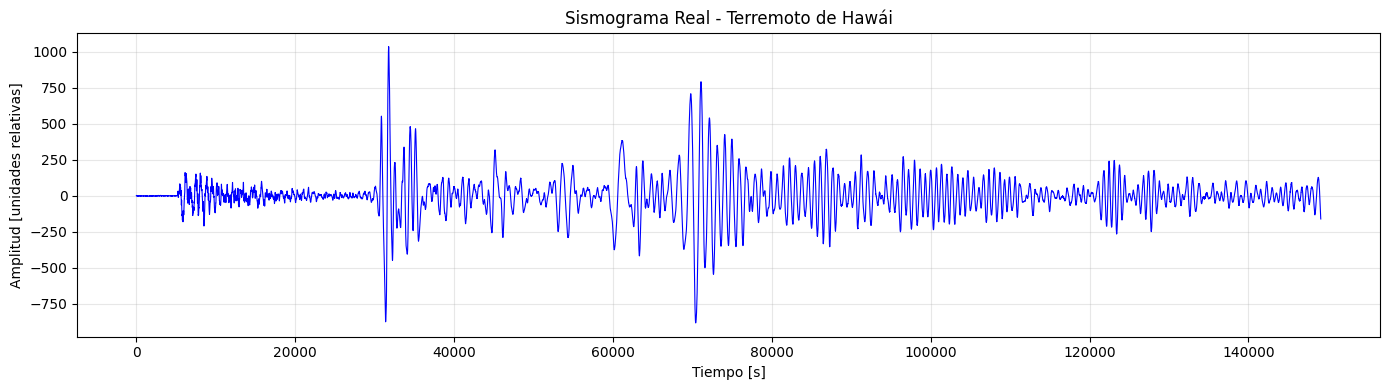

In [11]:
# =============================================================================
# SECCIÓN 0: CARGA Y VISUALIZACIÓN INICIAL DEL SISMOGRAMA
# PARTE INTEGRADA EN LA GUÍA
# =============================================================================

# URL del archivo de datos del sismograma real del terremoto de Hawái
url = ('https://github.com/LinkedEarth/PyRATES_practicums_py/raw/main'
       '/jbook/data/hawaii.e.dat')

# Leer el archivo; las columnas están separadas por espacios
# La primera columna es el tiempo [s] y la segunda la amplitud
df = pd.read_csv(url, sep=r'\s+', names=['tiempo_s', 'amplitud'], engine='python')

# El tiempo ya viene en segundos (no es necesario dividir entre 1000)
tiempo = df['tiempo_s'].values          # [s]

# Escalar amplitud para que sea más manejable visualmente
amplitud = df['amplitud'].values * 1e7  # [unidades relativas normalizadas]

# Calcular el intervalo de muestreo y la frecuencia de muestreo
dt = tiempo[1] - tiempo[0]             # paso temporal [s]
muestras_por_segundo = int(round(1 / dt))  # frecuencia de muestreo [Hz]

print(f"Datos cargados: {len(tiempo)} muestras")
print(f"Duración total: {tiempo[-1]:.2f} segundos")
print(f"Intervalo de muestreo dt: {dt:.4f} s")
print(f"Frecuencia de muestreo: {muestras_por_segundo} Hz")

# Visualización inicial del sismograma completo como referencia base
plt.figure(figsize=(14, 4))
plt.plot(tiempo, amplitud, 'b-', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [unidades relativas]')
plt.title('Sismograma Real - Terremoto de Hawái')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


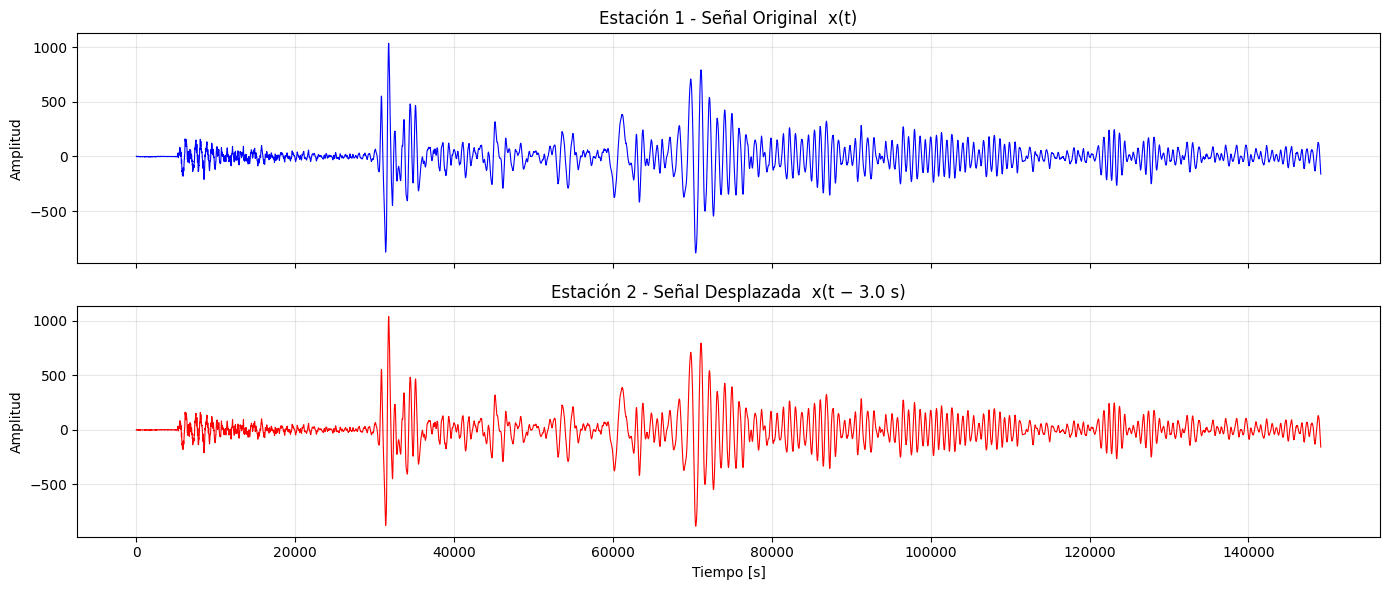

In [12]:
# =============================================================================
# SECCIÓN 4: TRANSFORMACIONES DE LA VARIABLE INDEPENDIENTE
# =============================================================================

# Función auxiliar reutilizable para desplazamiento temporal
def desplazar(arr, n_muestras):
    """
    Desplaza un arreglo n_muestras posiciones hacia la derecha.
    Simula un retardo temporal en la señal.
    Las muestras que "entran" por la izquierda se ponen en cero,
    eliminando el efecto circular de np.roll.
    """
    desplazado = np.roll(arr, n_muestras)
    if n_muestras > 0:
        desplazado[:n_muestras] = 0  # silencio antes de la llegada de la onda
    return desplazado


# -----------------------------------------------------------------------------
# 4.2 DESPLAZAMIENTO TEMPORAL
# x(t - t0): representa que la misma onda llega t0 segundos más tarde
# a una segunda estación más lejana del epicentro
# -----------------------------------------------------------------------------

# Retardo de 3 s → simula la diferencia de llegada entre dos estaciones
t0 = 3.0
n_shift = int(t0 * muestras_por_segundo)   # número de muestras equivalentes

# Desplazar la señal usando la función auxiliar
amplitud_desplazada = desplazar(amplitud, n_shift)

# Graficar señal original vs señal desplazada
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(tiempo, amplitud, 'b-', linewidth=0.8)
axes[0].set_title('Estación 1 - Señal Original  x(t)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, amplitud_desplazada, 'r-', linewidth=0.8)
axes[1].set_title(f'Estación 2 - Señal Desplazada  x(t − {t0} s)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo [s]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


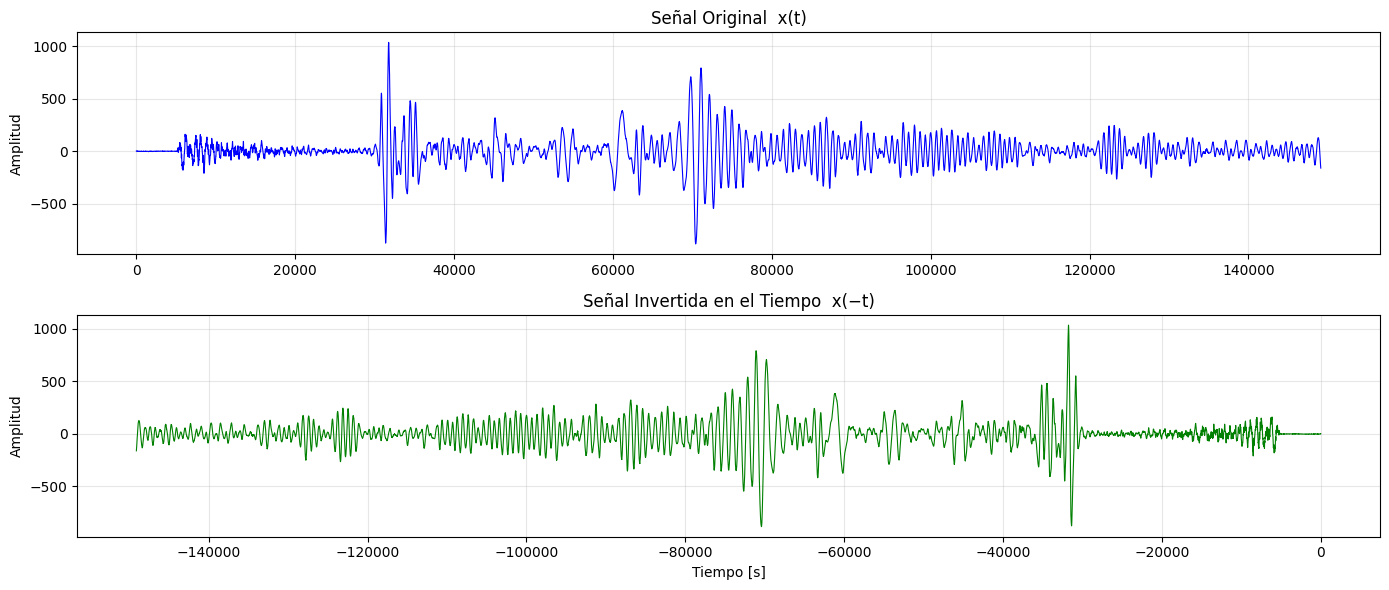

In [13]:
# -----------------------------------------------------------------------------
# 4.3 INVERSIÓN TEMPORAL
# x(-t): refleja la señal respecto al eje t = 0
# Invirtiendo el arreglo se obtiene el espejo temporal de la señal
# -----------------------------------------------------------------------------

# Invertir el orden del arreglo de amplitudes
amplitud_invertida = amplitud[::-1]

# El eje temporal también se invierte para representar t negativo
tiempo_invertido = -tiempo[::-1]

# Graficar señal original y señal invertida
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(tiempo, amplitud, 'b-', linewidth=0.8)
axes[0].set_title('Señal Original  x(t)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo_invertido, amplitud_invertida, 'g-', linewidth=0.8)
axes[1].set_title('Señal Invertida en el Tiempo  x(−t)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo [s]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


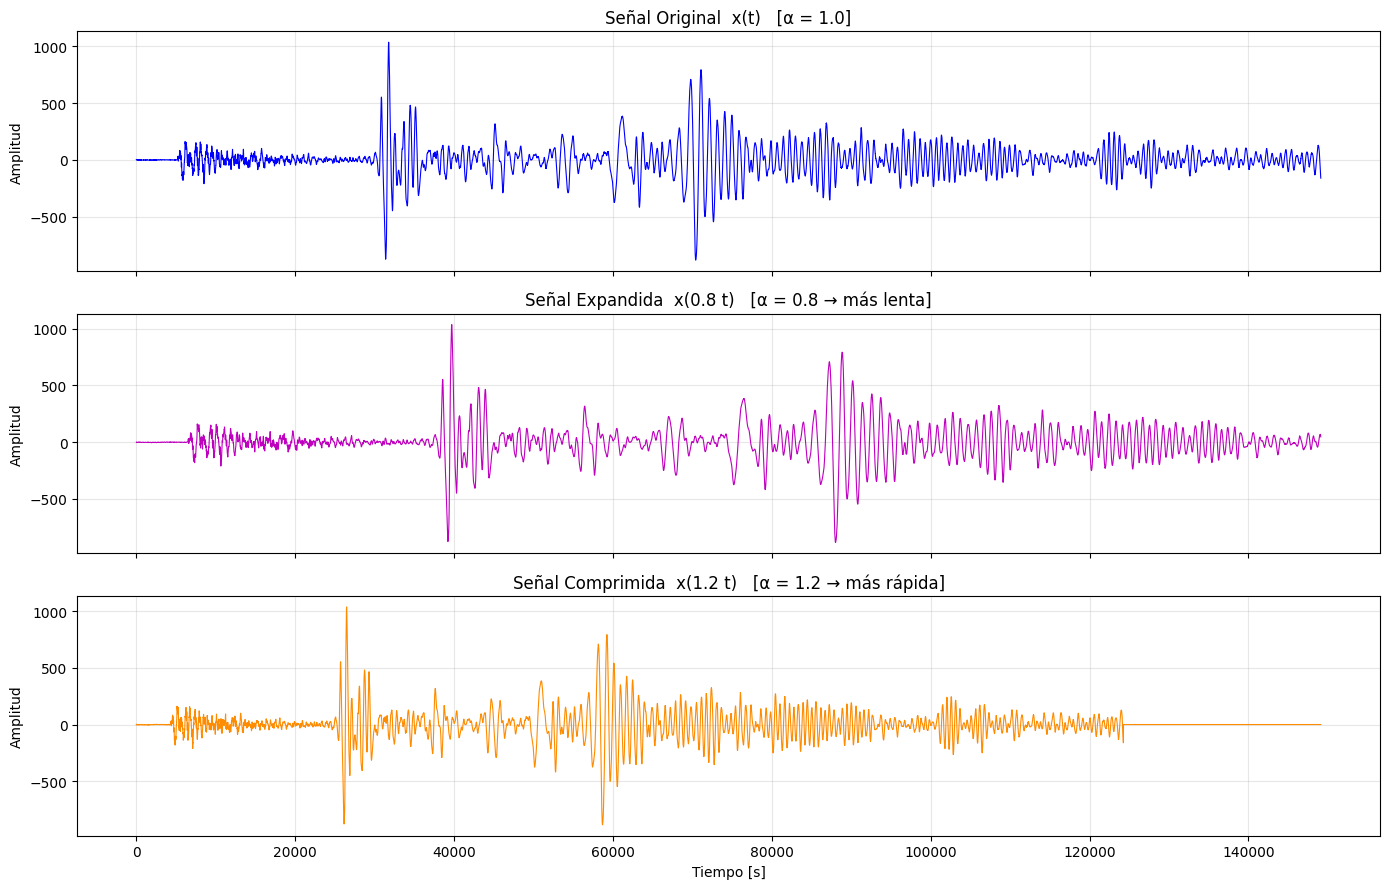

In [14]:
# -----------------------------------------------------------------------------
# 4.4 ESCALAMIENTO TEMPORAL
# x(αt): modifica la "velocidad" de la señal
#   α > 1 → compresión (la señal transcurre más rápido)
#   0 < α < 1 → expansión (la señal transcurre más lento)
# Se requiere interpolación porque α*tiempo no coincide con las muestras originales
# -----------------------------------------------------------------------------

def escalar_senal(tiempo_orig, amplitud_orig, alpha):
    """
    Escala el eje temporal de una señal discreta por el factor alpha.
    Usa interpolación lineal para estimar la amplitud en los nuevos instantes.

    Parámetros
    ----------
    tiempo_orig   : arreglo de tiempos de la señal original [s]
    amplitud_orig : arreglo de amplitudes de la señal original
    alpha         : factor de escala temporal (positivo)

    Retorna
    -------
    tiempo_orig   : mismo eje temporal (la escala se aplica internamente)
    amp_escalada  : amplitudes de x(α·t) evaluadas en los mismos instantes
    """
    # Construir interpolador sobre la señal original
    f_interp = interp1d(tiempo_orig, amplitud_orig,
                        kind='linear',
                        bounds_error=False,  # no error si α*t sale del rango
                        fill_value=0.0)      # cero fuera del dominio original

    # Evaluar la señal en α*t (escalar el argumento temporal)
    amp_escalada = f_interp(alpha * tiempo_orig)
    return tiempo_orig, amp_escalada


# α = 0.8 → expansión temporal (como si la onda viajara más lento)
_, amp_exp  = escalar_senal(tiempo, amplitud, alpha=0.8)

# α = 1.2 → compresión temporal (como si la onda viajara más rápido)
_, amp_comp = escalar_senal(tiempo, amplitud, alpha=1.2)

# Graficar las tres versiones para comparar el efecto del escalamiento
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(tiempo, amplitud, 'b-', linewidth=0.8)
axes[0].set_title('Señal Original  x(t)   [α = 1.0]')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, amp_exp, 'm-', linewidth=0.8)
axes[1].set_title('Señal Expandida  x(0.8 t)   [α = 0.8 → más lenta]')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True, alpha=0.3)

axes[2].plot(tiempo, amp_comp, 'darkorange', linewidth=0.8)
axes[2].set_title('Señal Comprimida  x(1.2 t)   [α = 1.2 → más rápida]')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Tiempo [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


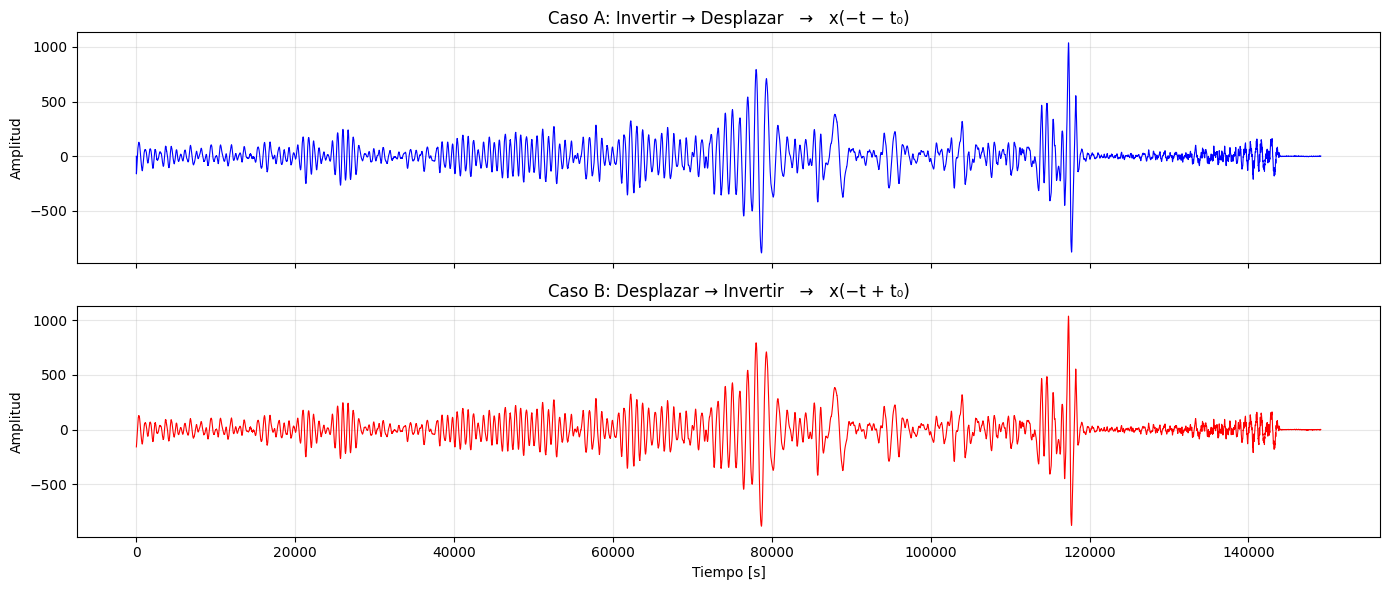

In [15]:
# -----------------------------------------------------------------------------
# 4.5 COMBINACIÓN DE TRANSFORMACIONES
# Caso A: invertir → desplazar  →  resultado: x(−t − t0)
# Caso B: desplazar → invertir  →  resultado: x(−t + t0)
# El orden de las operaciones importa; los resultados son distintos
# -----------------------------------------------------------------------------

# Número de muestras del retardo de 3 s
n_comb = int(3.0 * muestras_por_segundo)

# Caso A: primero invertir el arreglo, luego desplazar hacia la derecha
amp_invertida_A = amplitud[::-1]               # x(−t)
amp_caso_A = desplazar(amp_invertida_A, n_comb)  # x(−t − t0)

# Caso B: primero desplazar, luego invertir el arreglo
amp_desplazada_B = desplazar(amplitud, n_comb)   # x(t − t0)
amp_caso_B = amp_desplazada_B[::-1]              # x(−(t − t0)) = x(−t + t0)

# Graficar ambos casos para comparar
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(tiempo, amp_caso_A, 'b-', linewidth=0.8)
axes[0].set_title('Caso A: Invertir → Desplazar   →   x(−t − t₀)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, amp_caso_B, 'r-', linewidth=0.8)
axes[1].set_title('Caso B: Desplazar → Invertir   →   x(−t + t₀)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo [s]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()



Energía señal original:     3087321343.830848
Energía sismograma total:   6051292230.891758
Razón E_total / E_orig:     1.9600


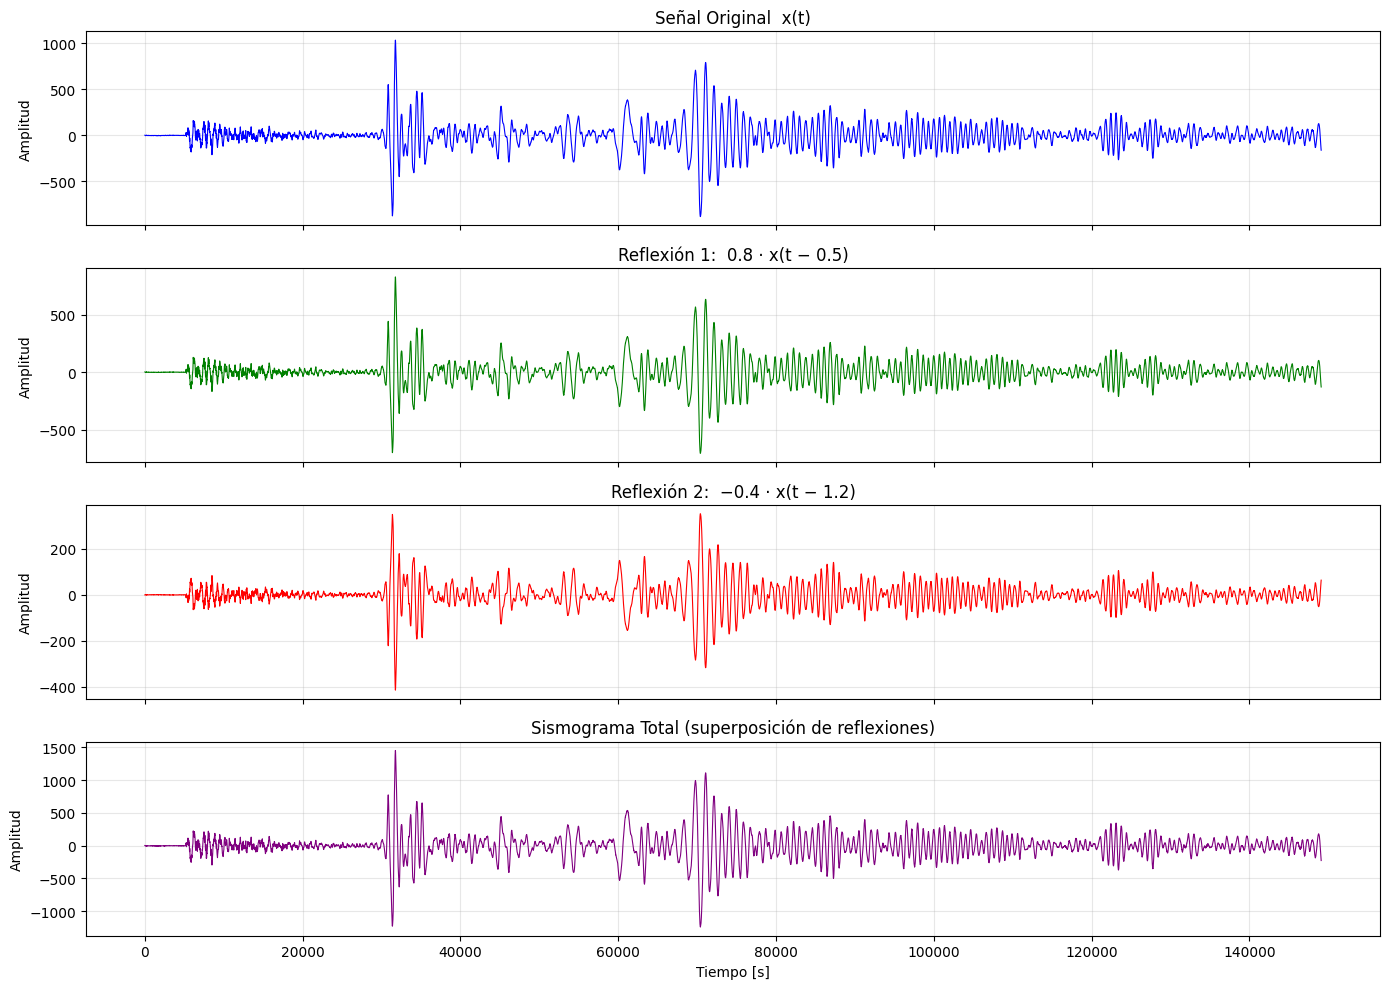

In [16]:
# =============================================================================
# SECCIÓN 5: OPERACIONES ENTRE SEÑALES
# =============================================================================

# -----------------------------------------------------------------------------
# 5.1 SUMA DE SEÑALES - MÚLTIPLES REFLEXIONES
# Modela la superposición de ondas sísmicas reflejadas en distintas capas:
#   Señal 1: reflexión con 80% de amplitud y retardo de 0.5 s
#   Señal 2: reflexión invertida (contraste de impedancia negativo) con 40%
#            de amplitud y retardo de 1.2 s
# La suma produce interferencia constructiva y destructiva
# -----------------------------------------------------------------------------

# Señal 1: reflexión atenuada al 80%, desplazada 0.5 s
n_r1 = int(0.5 * muestras_por_segundo)
senal_1 = 0.8 * desplazar(amplitud, n_r1)

# Señal 2: reflexión de polaridad inversa al 40%, desplazada 1.2 s
n_r2 = int(1.2 * muestras_por_segundo)
senal_2 = -0.4 * desplazar(amplitud, n_r2)

# Sismograma resultante: suma de la señal original y las dos reflexiones
sismograma_total = amplitud + senal_1 + senal_2

# Calcular la energía de cada señal (suma de cuadrados × dt)
dt_ = dt
energia_orig  = np.sum(amplitud**2) * dt_
energia_total = np.sum(sismograma_total**2) * dt_
print(f"\nEnergía señal original:     {energia_orig:.6f}")
print(f"Energía sismograma total:   {energia_total:.6f}")
print(f"Razón E_total / E_orig:     {energia_total / energia_orig:.4f}")

# Graficar señal original, reflexiones y suma total
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(tiempo, amplitud, 'b-', linewidth=0.8)
axes[0].set_title('Señal Original  x(t)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, senal_1, 'g-', linewidth=0.8)
axes[1].set_title('Reflexión 1:  0.8 · x(t − 0.5)')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True, alpha=0.3)

axes[2].plot(tiempo, senal_2, 'r-', linewidth=0.8)
axes[2].set_title('Reflexión 2:  −0.4 · x(t − 1.2)')
axes[2].set_ylabel('Amplitud')
axes[2].grid(True, alpha=0.3)

axes[3].plot(tiempo, sismograma_total, 'purple', linewidth=0.8)
axes[3].set_title('Sismograma Total (superposición de reflexiones)')
axes[3].set_ylabel('Amplitud')
axes[3].set_xlabel('Tiempo [s]')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()



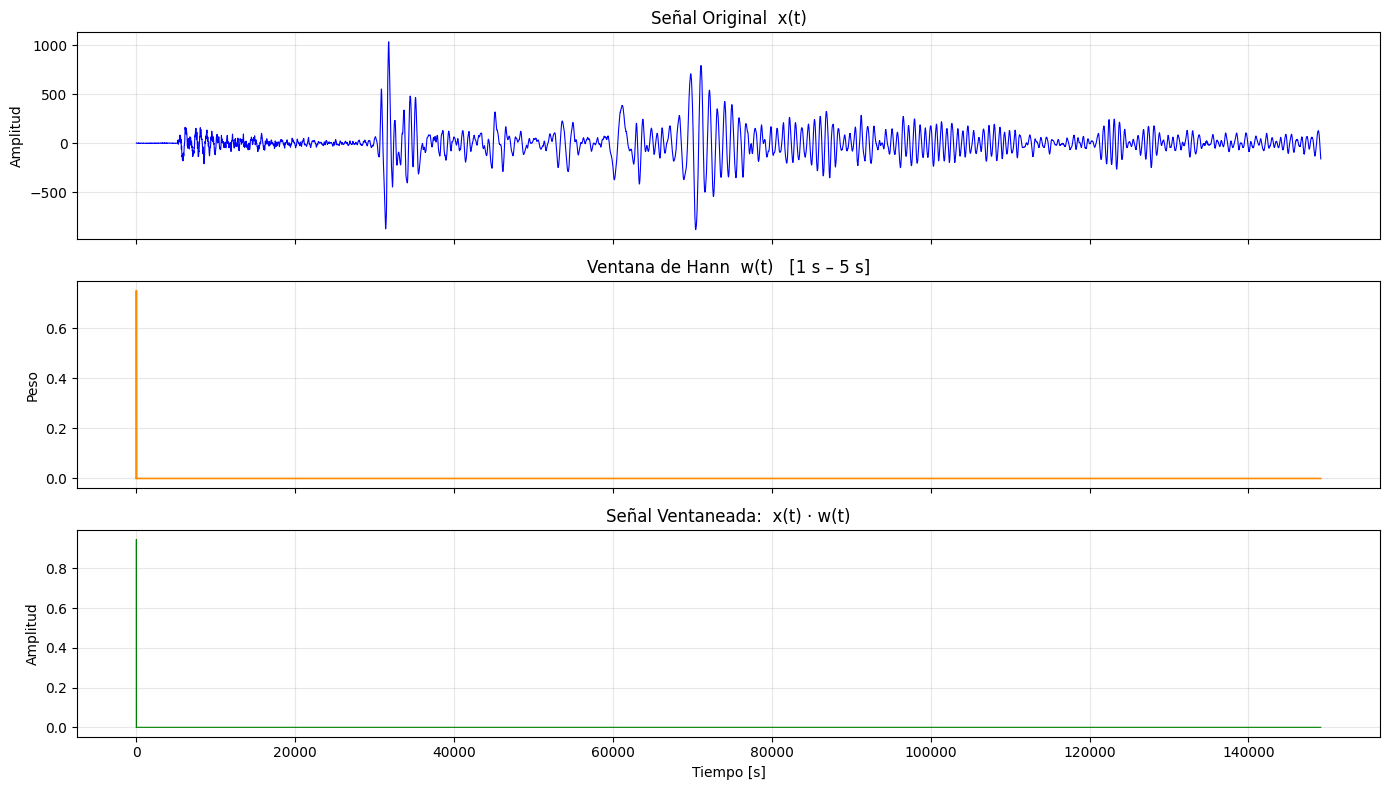

In [17]:
# -----------------------------------------------------------------------------
# 5.2 PRODUCTO DE SEÑALES - VENTANEO CON VENTANA DE HANN
# Multiplicar por una ventana que sube y baja suavemente evita el
# "efecto Gibbs" (artefactos espectrales) que genera un corte abrupto
# -----------------------------------------------------------------------------

def ventana_hann(t, t_inicio, t_fin):
    """
    Genera una ventana de Hann sobre el intervalo [t_inicio, t_fin].
    Fuera de ese intervalo vale 0; dentro sigue la curva coseno suave.

    Parámetros
    ----------
    t        : eje temporal de la señal
    t_inicio : tiempo de inicio de la ventana [s]
    t_fin    : tiempo de fin de la ventana [s]

    Retorna
    -------
    ventana  : arreglo con los pesos de la ventana de Hann
    """
    ventana = np.zeros_like(t)
    mask = (t >= t_inicio) & (t <= t_fin)
    indices = np.where(mask)[0]
    if len(indices) > 0:
        n = len(indices)
        # Fórmula estándar: w[k] = 0.5 · (1 − cos(2π·k / (N−1)))
        hann = 0.5 * (1 - np.cos(2 * np.pi * np.arange(n) / (n - 1)))
        ventana[indices] = hann
    return ventana


# Crear ventana entre 1 s y 5 s para aislar la fase de interés del sismograma
ventana = ventana_hann(tiempo, t_inicio=1.0, t_fin=5.0)

# Aplicar el ventaneo: producto punto a punto de señal y ventana
amplitud_ventaneada = amplitud * ventana

# Graficar la ventana, la señal original y la señal ventaneada
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tiempo, amplitud, 'b-', linewidth=0.8)
axes[0].set_title('Señal Original  x(t)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, ventana, 'darkorange', linewidth=1.2)
axes[1].set_title('Ventana de Hann  w(t)   [1 s – 5 s]')
axes[1].set_ylabel('Peso')
axes[1].grid(True, alpha=0.3)

axes[2].plot(tiempo, amplitud_ventaneada, 'g-', linewidth=0.8)
axes[2].set_title('Señal Ventaneada:  x(t) · w(t)')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Tiempo [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()



Verificación de conservación de energía (Sección 6):
  E[x(t)]       = 3087321343.830848
  E[xe(t)]      = 1820973009.854222
  E[xo(t)]      = 1266348333.976627
  E[xe] + E[xo] = 3087321343.830849
  Error relativo = 0.0000 %


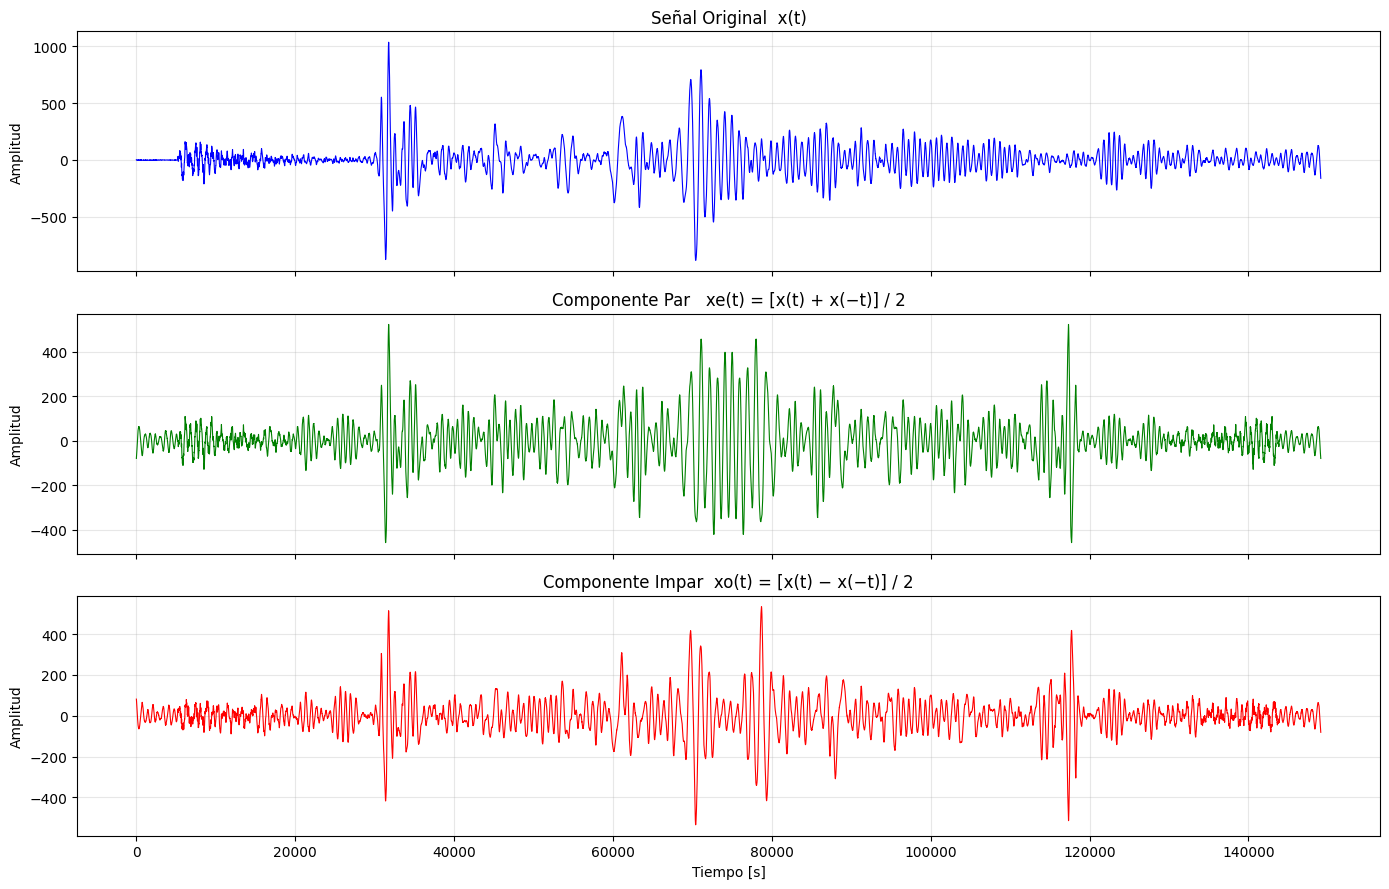

In [18]:
# =============================================================================
# SECCIÓN 6: DESCOMPOSICIÓN EN COMPONENTES PAR E IMPAR
# =============================================================================

def descomponer_par_impar(senal):
    """
    Descompone una señal discreta en su parte par y su parte impar.

    Definiciones:
        Parte par   xe(t) = [x(t) + x(−t)] / 2
        Parte impar xo(t) = [x(t) − x(−t)] / 2

    Para señales discretas, x(−t) se obtiene invirtiendo el arreglo.
    Se recortan ambas versiones a la longitud mínima para alinearlas.

    Retorna
    -------
    par   : componente par  xe
    impar : componente impar xo
    """
    senal_inv = senal[::-1]                     # inversión: x(−t)
    n = min(len(senal), len(senal_inv))         # longitud mínima (por seguridad)
    s  = senal[:n]
    si = senal_inv[:n]
    par   = (s + si) / 2.0
    impar = (s - si) / 2.0
    return par, impar


# Descomponer el sismograma real en sus componentes par e impar
par, impar = descomponer_par_impar(amplitud)
n_par = len(par)          # longitud efectiva después del recorte

# Verificar la conservación de energía:
# ∫ x²(t) dt ≈ ∫ xe²(t) dt + ∫ xo²(t) dt
E_x     = np.sum(amplitud[:n_par]**2) * dt
E_par   = np.sum(par**2) * dt
E_impar = np.sum(impar**2) * dt

print(f"\nVerificación de conservación de energía (Sección 6):")
print(f"  E[x(t)]       = {E_x:.6f}")
print(f"  E[xe(t)]      = {E_par:.6f}")
print(f"  E[xo(t)]      = {E_impar:.6f}")
print(f"  E[xe] + E[xo] = {E_par + E_impar:.6f}")
print(f"  Error relativo = {abs(E_x - (E_par + E_impar)) / E_x * 100:.4f} %")

# Graficar señal original y sus dos componentes
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(tiempo[:n_par], amplitud[:n_par], 'b-', linewidth=0.8)
axes[0].set_title('Señal Original  x(t)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo[:n_par], par, 'g-', linewidth=0.8)
axes[1].set_title('Componente Par   xe(t) = [x(t) + x(−t)] / 2')
axes[1].set_ylabel('Amplitud')
axes[1].grid(True, alpha=0.3)

axes[2].plot(tiempo[:n_par], impar, 'r-', linewidth=0.8)
axes[2].set_title('Componente Impar  xo(t) = [x(t) − x(−t)] / 2')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Tiempo [s]')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()



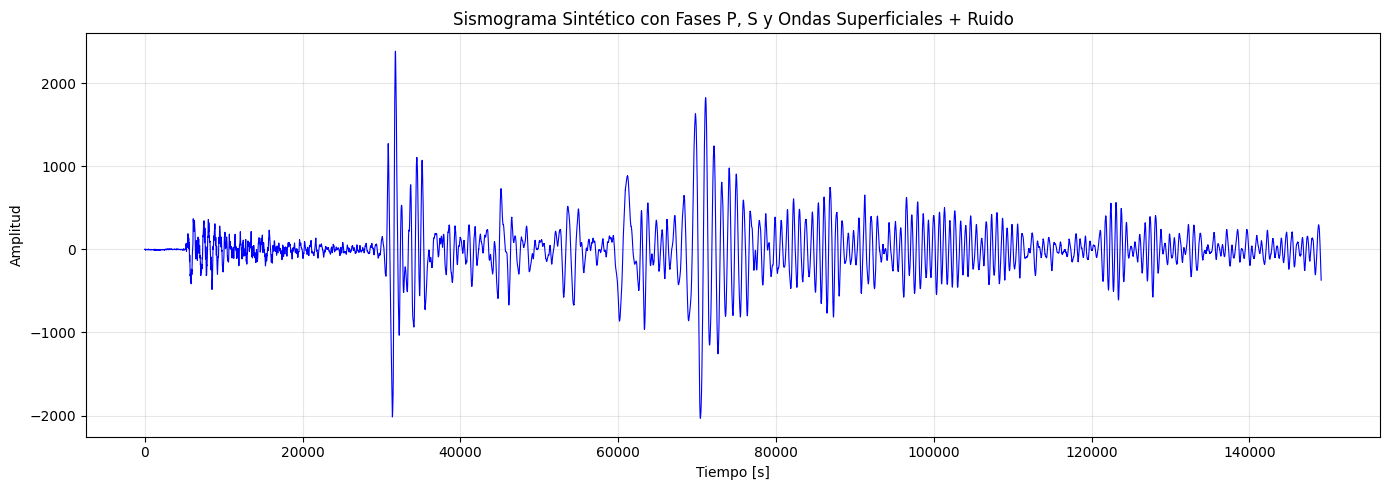

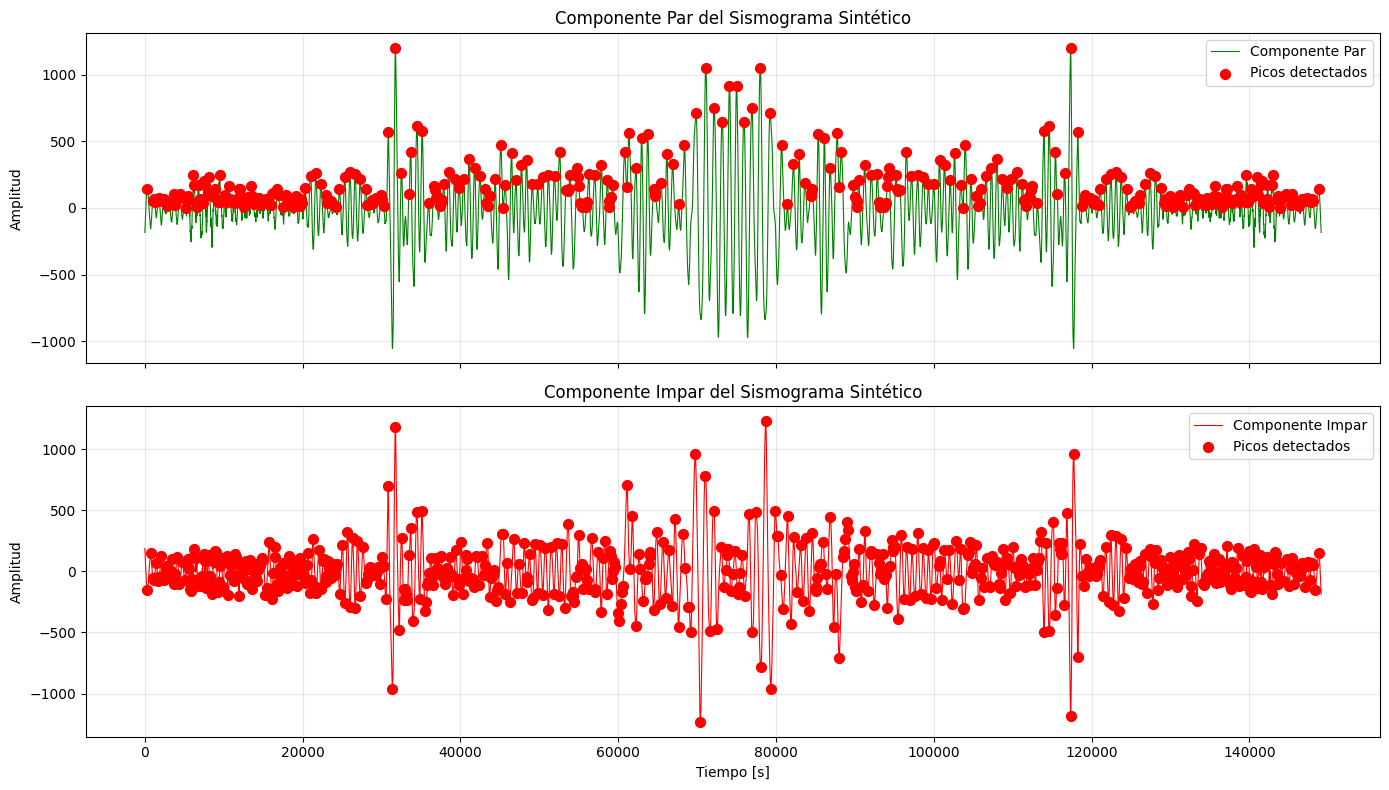

In [19]:
# =============================================================================
# SECCIÓN 7: INTEGRACIÓN Y DESAFÍO FINAL
# =============================================================================

# -----------------------------------------------------------------------------
# 7.1 SISMOGRAMA SINTÉTICO
# Superpone tres fases sísmicas desfasadas con distinta amplitud:
#   Fase P     : onda compresional, llega primero (más rápida)
#   Fase S     : onda de corte, llega después y con mayor amplitud
#   Superficial: ondas de superficie, filtradas (bajas frecuencias) y más tardías
# Se agrega ruido gaussiano para simular condiciones reales de registro
# -----------------------------------------------------------------------------

# Fase P: 60% de amplitud, retardada 0.3 s
fase_P = amplitud.copy() * 0.6
fase_P = desplazar(fase_P, int(0.3 * muestras_por_segundo))

# Fase S: 120% de amplitud (más energética que P), retardada 0.8 s
fase_S = amplitud.copy() * 1.2
fase_S = desplazar(fase_S, int(0.8 * muestras_por_segundo))

# Ondas superficiales: 50% de amplitud, suavizadas con Savitzky-Golay
# El filtro actúa como un paso-bajas preservando la forma del pulso
onda_superficial = amplitud.copy() * 0.5
onda_superficial = signal.savgol_filter(onda_superficial, 51, 3)
onda_superficial = desplazar(onda_superficial, int(1.5 * muestras_por_segundo))

# Sismograma sintético: superposición lineal de las tres fases
sismograma_sintetico = fase_P + fase_S + onda_superficial

# Añadir ruido gaussiano (media 0, desviación estándar 0.15)
np.random.seed(42)    # semilla fija para reproducibilidad
ruido = np.random.normal(0, 0.15, size=len(sismograma_sintetico))
sismograma_ruidoso = sismograma_sintetico + ruido

# Graficar el sismograma sintético con ruido
plt.figure(figsize=(14, 5))
plt.plot(tiempo, sismograma_ruidoso, 'b-', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Sismograma Sintético con Fases P, S y Ondas Superficiales + Ruido')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


# -----------------------------------------------------------------------------
# 7.2 DESAFÍO FINAL: DETECCIÓN DE PICOS EN COMPONENTES PAR E IMPAR
# Descomponemos el sismograma sintético y buscamos picos locales en cada componente.
# Los picos en la parte par corresponden a estructuras simétricas (reflexiones),
# y los de la parte impar a transiciones abruptas o cambios de polaridad.
# -----------------------------------------------------------------------------

def detectar_picos(senal, altura_min=0.3, distancia_min=100):
    """
    Detecta picos locales en una señal usando scipy.signal.find_peaks.

    Parámetros
    ----------
    senal        : arreglo 1D de amplitudes
    altura_min   : amplitud mínima del pico para ser considerado
    distancia_min: separación mínima entre picos consecutivos (en muestras)

    Retorna
    -------
    picos : índices de los picos encontrados
    """
    picos = signal.find_peaks(senal,
                              height=altura_min,
                              distance=distancia_min)[0]
    return picos


# Descomponer el sismograma ruidoso en par e impar
par_sint, impar_sint = descomponer_par_impar(sismograma_ruidoso)
n_sint = len(par_sint)
tiempo_sint = tiempo[:n_sint]

# Detectar picos positivos en la componente par
picos_par   = detectar_picos(par_sint)

# Detectar picos en el módulo de la componente impar
# (captura tanto transiciones positivas como negativas)
picos_impar = detectar_picos(np.abs(impar_sint))

# Graficar componentes con sus picos marcados en rojo
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tiempo_sint, par_sint, 'g-', linewidth=0.8, label='Componente Par')
axes[0].scatter(tiempo_sint[picos_par], par_sint[picos_par],
                color='red', s=50, zorder=5, label='Picos detectados')
axes[0].set_title('Componente Par del Sismograma Sintético')
axes[0].set_ylabel('Amplitud')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo_sint, impar_sint, 'r-', linewidth=0.8, label='Componente Impar')
axes[1].scatter(tiempo_sint[picos_impar], impar_sint[picos_impar],
                color='red', s=50, zorder=5, label='Picos detectados')
axes[1].set_title('Componente Impar del Sismograma Sintético')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo [s]')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()


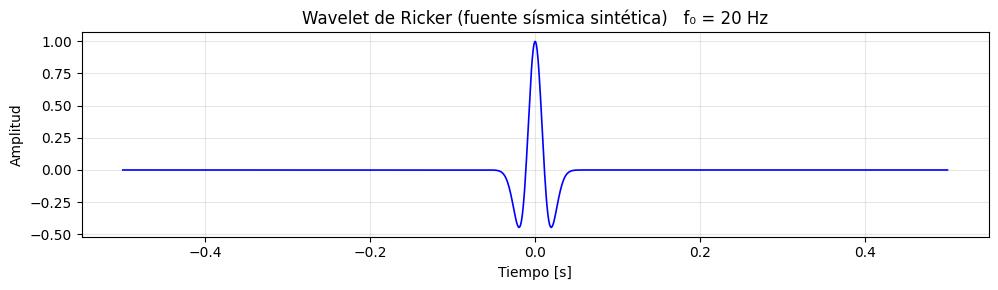

In [20]:
# =============================================================================
# APÉNDICE: WAVELET DE RICKER
# La wavelet de Ricker es la segunda derivada de una gaussiana.
# Modela de forma simple el pulso emitido por una fuente sísmica puntual.
# El parámetro f0 controla la frecuencia dominante del pulso [Hz].
# =============================================================================

def ricker(t, f0=10.0):
    """
    Genera una wavelet de Ricker de frecuencia dominante f0 [Hz].
    Fórmula: w(t) = (1 − 2·(π·f0·t)²) · exp(−(π·f0·t)²)

    Parámetros
    ----------
    t  : arreglo de tiempos centrado en 0 [s]
    f0 : frecuencia dominante [Hz]

    Retorna
    -------
    Arreglo con la wavelet evaluada en cada instante t
    """
    tau = np.pi * f0 * t
    return (1 - 2 * tau**2) * np.exp(-tau**2)


# Generar y graficar la wavelet con frecuencia dominante de 20 Hz
t_ricker = np.linspace(-0.5, 0.5, 1000)
ricker_signal = ricker(t_ricker, f0=20)

plt.figure(figsize=(10, 3))
plt.plot(t_ricker, ricker_signal, 'b-', linewidth=1.2)
plt.title('Wavelet de Ricker (fuente sísmica sintética)   f₀ = 20 Hz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(f"figuras/fig_{plt.gcf().number:02d}.png", dpi=100, bbox_inches="tight")
plt.show()